### **Оптимизация системы с ограниченной очередью**

**Цель работы:**
Исследовать характеристики системы массового обслуживания с ограниченной очередью (M/M/1/m) и определить оптимальные параметры системы для минимизации потерь заявок и времени ожидания.

**Задачи:**

1. Разработать математическую модель системы с ограниченной очередью.
2. Провести расчёты основных характеристик системы.
3. Определить оптимальную длину очереди, при которой вероятность потерь не превышает 5%.
4. Проанализировать влияние параметров системы на её эффективность.

**Исходные данные:**

- Интенсивность входящего потока заявок (λ): 8 заявок/час.
- Интенсивность обслуживания (μ): 10 заявок/час.
- Максимальная длина очереди (m): 5 заявок.
- Порог вероятности потерь: не более 5%.

### Шаг 1. Разработка модели

_Опишите систему массового обслуживания с ограниченной очередью (M/M/1/m)._

_Учтите, что заявки, поступающие в систему, теряются, если очередь заполнена._

**СМО** — окно МФЦ: один сотрудник, зал ожидания на m мест. Посетитель, вошедший в переполненный зал, разворачивается и уходит — заявка теряется
безвозвратно.

Нотация Кендалла: **M/M/1/m**
- **M** — пуассоновский входящий поток (посетители независимы, интервалы экспоненциальны)
- **M** — экспоненциальное время обслуживания
- **1** — один сотрудник (канал)
- **m** — максимальное число мест в зале ожидания

Всего в системе одновременно может находиться не более **m + 1** человек: один у сотрудника и m в зале.

Работа системы:
1. Посетитель приходит.
2. Если сотрудник свободен — обслуживание начинается немедленно.
3. Если занят, но в зале есть место — посетитель садится ждать.
4. Если зал полон — посетитель уходит (потеря).
5. Сотрудник заканчивает приём, берёт первого из зала.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import heapq
from IPython.display import display

np.random.seed(42)

ARRIVAL_RATE    = 8     # λ — заявок/час
SERVICE_RATE    = 10    # μ — заявок/час
MAX_QUEUE       = 5     # m — мест в зале ожидания
LOSS_THRESHOLD  = 0.05  # порог вероятности потерь
SIMULATION_TIME = 2000  # T — часов

### Шаг 2. Расчёт характеристик системы

_Рассчитайте следующие показатели:_
- _Вероятность потери заявок (вероятность того, что очередь заполнена)._
- _Среднее число заявок в очереди._
- _Среднее время ожидания заявки в очереди._
- _Среднее время пребывания заявки в системе._
- _Коэффициент загрузки системы._

Используем событийное моделирование с двумя типами событий: **прибытие** и **освобождение сотрудника**. Все события хранятся в куче (`heapq`) —
она всегда возвращает ближайшее по времени событие. Интегралы для $L_q$ и $P_0$ накапливаются перед каждым событием: текущее состояние системы умножается на длину прошедшего промежутка $dt$.

Все показатели вычисляются из данных симуляции. Обозначения:

| Величина | Формула | Смысл |
|---|---|---|
| $\hat{P}_{\text{loss}}$ | $\dfrac{N_{\text{потеряно}}}{N_{\text{пришло}}}$ | Доля потерянных посетителей |
| $\hat{L}_q$ | $\dfrac{1}{T}\displaystyle\int_0^T q(t)\,dt$ | Ср. число ожидающих в зале (интеграл по времени) |
| $\hat{W}_q$ | $\dfrac{\sum w_i}{N_{\text{обслужено}}}$ | Ср. время ожидания обслуженного посетителя |
| $\hat{W}$ | $\hat{W}_q + \dfrac{1}{\mu}$ | Ср. полное время в МФЦ |
| $\hat{\rho}$ | $\dfrac{\text{время занятости сотрудника}}{T}$ | Коэффициент загрузки |

**$\hat{W}_q$:** ожидание усредняется только по *обслуженным* посетителям — те, кто ушёл из-за полного зала, в среднее не включаются (они не ждали, они потерялись).

Связь $\hat{L}_q$ и $\hat{W}_q$ через закон Литтла применяется к эффективному потоку $\lambda_{\text{eff}} = \lambda(1 - \hat{P}_{\text{loss}})$:
$$L_q = \lambda_{\text{eff}} \cdot W_q$$

In [2]:
def simulate(lam, mu, m, T):
    events = []  # куча событий: (время, тип)  0=прибытие, 1=уход из системы
    heapq.heappush(events, (np.random.exponential(1 / lam), 0))

    server_busy = False  # занят ли сотрудник
    queue = []           # зал ожидания: времена прихода ждущих посетителей

    total_arrived = 0
    total_served  = 0
    total_lost    = 0
    sum_wait      = 0.0
    busy_time     = 0.0

    queue_area = 0.0  # интеграл q(t) — для Lq
    idle_area  = 0.0  # интеграл простоя — для P0
    last_t     = 0.0

    while events:
        t, etype = heapq.heappop(events)
        if t > T:
            break

        dt = t - last_t
        queue_area += len(queue) * dt      # накапливаем площадь очереди
        if not server_busy:
            idle_area += dt                # накапливаем время простоя
        last_t = t

        if etype == 0:  # прибытие
            heapq.heappush(events, (t + np.random.exponential(1 / lam), 0))  # следующий приход
            total_arrived += 1

            if not server_busy:
                # сотрудник свободен — сразу к нему
                server_busy = True
                svc = np.random.exponential(1 / mu)
                busy_time += svc
                total_served += 1
                heapq.heappush(events, (t + svc, 1))
            elif len(queue) < m:
                # зал не полон — садимся ждать
                queue.append(t)
            else:
                # зал полон — потеря
                total_lost += 1

        else:  # освобождение сотрудника
            if queue:
                # берём первого из зала
                arrived_at = queue.pop(0)
                wait = t - arrived_at      # ждал от прихода до начала приёма
                sum_wait += wait
                svc = np.random.exponential(1 / mu)
                busy_time += svc
                total_served += 1
                heapq.heappush(events, (t + svc, 1))
            else:
                # зал пуст — сотрудник свободен
                server_busy = False

    P_loss = total_lost / total_arrived if total_arrived else 0
    P0     = idle_area / T
    Lq     = queue_area / T
    Wq     = sum_wait / total_served if total_served else 0
    W      = Wq + 1 / mu
    rho    = busy_time / T

    return {
        "Пришло":                        total_arrived,
        "Обслужено":                      total_served,
        "Потеряно":                       total_lost,
        "P_loss (вероятность потери)":    round(P_loss, 4),
        "P0    (простой сотрудника)":     round(P0,     4),
        "Lq    (ср. очередь)": round(Lq,     4),
        "Wq    (ср. ожидание, ч)": round(Wq,     4),
        "W     (ср. время в МФЦ, ч)": round(W,      4),
        "ρ     (загрузка сотрудника)": round(rho,    4)
    }

result = simulate(ARRIVAL_RATE, SERVICE_RATE, MAX_QUEUE, SIMULATION_TIME)
print(f"Результаты симуляции (λ={ARRIVAL_RATE}, μ={SERVICE_RATE}, m={MAX_QUEUE}):")
for k, v in result.items():
    print(f"  {k}: {v}")

Результаты симуляции (λ=8, μ=10, m=5):
  Пришло: 15974
  Обслужено: 14929
  Потеряно: 1043
  P_loss (вероятность потери): 0.0653
  P0    (простой сотрудника): 0.2586
  Lq    (ср. очередь): 1.3755
  Wq    (ср. ожидание, ч): 0.1843
  W     (ср. время в МФЦ, ч): 0.2843
  ρ     (загрузка сотрудника): 0.7414


### Шаг 3 Сравнение симуляции с теоретическими формулами

Для M/M/1/m существует точное стационарное решение через геометрическое распределение.

**Теоретические формулы** (ρ = λ/μ, ρ ≠ 1):

$$P_k = \frac{1-\rho}{1-\rho^{m+2}}\,\rho^k, \quad k = 0,1,\ldots,m+1$$

$$P_{\text{loss}} = P_{m+1}, \quad
L_q = \sum_{k=1}^{m}(k-1)\,P_k \cdot \mathbf{1}[\text{канал занят}]$$

$$W_q = \frac{L_q}{\lambda\,(1-P_{\text{loss}})}$$

In [6]:
def mm1m_theory(lam, mu, m):
    rho = lam / mu
    capacity = m + 1  # всего мест в системе: 1 у сотрудника + m в зале

    if abs(rho - 1) < 1e-9:
        P = [1 / (capacity + 1)] * (capacity + 1)
    else:
        P = [(1 - rho) / (1 - rho**(capacity + 1)) * rho**k for k in range(capacity + 1)]

    P_loss = P[capacity]                         # вероятность потери (система полна)
    Lq     = sum((k - 1) * P[k] for k in range(2, capacity + 1))  # очередь без сотрудника
    lam_eff = lam * (1 - P_loss)
    Wq     = Lq / lam_eff if lam_eff > 0 else 0

    return {"P_loss_theory": P_loss, "Lq_theory": Lq, "Wq_theory (ч)": Wq, "P0_theory": P[0]}

theory = mm1m_theory(ARRIVAL_RATE, SERVICE_RATE, MAX_QUEUE)
sim    = simulate(ARRIVAL_RATE, SERVICE_RATE, MAX_QUEUE, SIMULATION_TIME)

comparison = pd.DataFrame({
    "Симуляция": [
        sim["P_loss (вероятность потери)"],
        sim["Lq    (ср. очередь)"],
        sim["Wq    (ср. ожидание, ч)"],
        sim["P0    (простой сотрудника)"],
    ],
    "Теория": [
        theory["P_loss_theory"],
        theory["Lq_theory"],
        theory["Wq_theory (ч)"],
        theory["P0_theory"],
    ]
}, index=["P_loss", "Lq", "Wq (ч)", "P0"])

comparison["Δ, %"] = ((comparison["Симуляция"] - comparison["Теория"]) / comparison["Теория"] * 100).round(2)
print(comparison.round(4))

        Симуляция  Теория  Δ, %
P_loss     0.0695  0.0663  4.76
Lq         1.3866  1.3955 -0.64
Wq (ч)     0.1888  0.1868  1.05
P0         0.2540  0.2531  0.37


### Шаг 4. Оптимизация длины очереди

_Проведите расчёты для различных значений длины очереди (m)._

_Определите оптимальную длину очереди, при которой вероятность потерь не превышает 5%._

Перебираем m от 0 до 20 и ищем минимальное значение, при котором $\hat{P}_{\text{loss}} \leq 5\%$. При m=0 посетитель теряется, если сотрудник уже занят, — система вырождается в M/M/1/0 (только одно место, отказы без ожидания).

In [9]:
rows_m = []
optimal_m = None

for m in range(0, 21):
    r = simulate(ARRIVAL_RATE, SERVICE_RATE, m, SIMULATION_TIME)
    rows_m.append({
        "m (мест в зале)": m,
        "P_loss": r["P_loss (вероятность потери)"],
        "Lq":     r["Lq    (ср. очередь)"],
        "Wq, ч":  r["Wq    (ср. ожидание, ч)"],
        "W, ч":   r["W     (ср. время в МФЦ, ч)"],
        "ρ":      r["ρ     (загрузка сотрудника)"],
        "P0":     r["P0    (простой сотрудника)"]
    })
    if optimal_m is None and r["P_loss (вероятность потери)"] <= LOSS_THRESHOLD:
        optimal_m = m

df_m = pd.DataFrame(rows_m)
display(df_m)

print(f"\nМинимальное m при P_loss ≤ {LOSS_THRESHOLD*100:.0f}%: m* = {optimal_m}")

,m (мест в зале),P_loss,Lq,"Wq, ч","W, ч",ρ,P0
0,0,0.4411,0.0000,0.0000,0.1000,0.4446,0.5555
1,1,0.2561,0.2626,0.0442,0.1442,0.5901,0.4100
2,2,0.1748,0.5683,0.0851,0.1851,0.6671,0.3330
3,3,0.1228,0.8498,0.1209,0.2209,0.6958,0.3042
4,4,0.0860,1.1198,0.1532,0.2532,0.7203,0.2798
5,5,0.0721,1.4399,0.1921,0.2921,0.7521,0.2480
6,6,0.0550,1.7049,0.2259,0.3259,0.7659,0.2341
7,7,0.0391,1.9062,0.2466,0.3466,0.7735,0.2266
8,8,0.0311,2.0666,0.2649,0.3649,0.7846,0.2155
9,9,0.0225,2.1836,0.2801,0.3801,0.7771,0.2229



Минимальное m при P_loss ≤ 5%: m* = 7


### Шаг 5. Анализ результатов

_Постройте графики зависимости вероятности потерь и среднего времени ожидания от длины очереди._

_Сделайте выводы о влиянии длины очереди на эффективность системы._

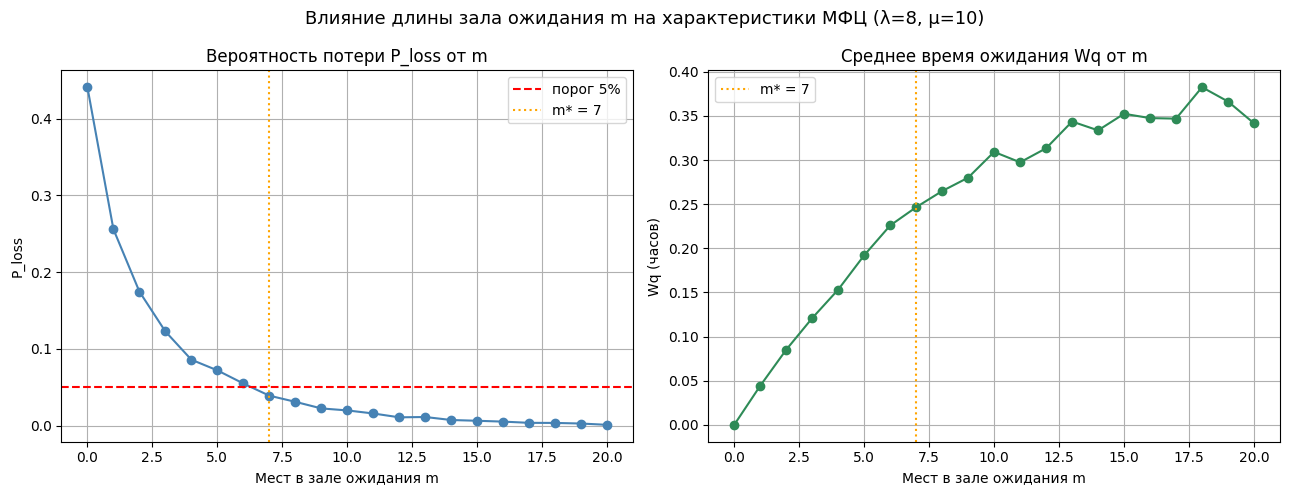

In [18]:
plt.style.use("default")
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ms = df_m["m (мест в зале)"]

# вероятность потери P_loss от вместимости очереди m
ax = axes[0]
ax.plot(ms, df_m["P_loss"], marker="o", color="steelblue")
ax.axhline(y=LOSS_THRESHOLD, color="red", linestyle="--", label=f"порог {LOSS_THRESHOLD*100:.0f}%")
if optimal_m is not None:
    ax.axvline(x=optimal_m, color="orange", linestyle=":", label=f"m* = {optimal_m}")
ax.set_title("Вероятность потери P_loss от m")
ax.set_xlabel("Мест в зале ожидания m")
ax.set_ylabel("P_loss")
ax.legend(); ax.grid(True)

# Wq от m
ax = axes[1]
ax.plot(ms, df_m["Wq, ч"], marker="o", color="seagreen")
if optimal_m is not None:
    ax.axvline(x=optimal_m, color="orange", linestyle=":", label=f"m* = {optimal_m}")
ax.set_title("Среднее время ожидания Wq от m")
ax.set_xlabel("Мест в зале ожидания m")
ax.set_ylabel("Wq (часов)")
ax.legend(); ax.grid(True)

plt.suptitle(f"Влияние длины зала ожидания m на характеристики МФЦ (λ={ARRIVAL_RATE}, μ={SERVICE_RATE})", fontsize=13)
plt.tight_layout()
plt.show()

### Анализ результатов

#### Базовые параметры (λ=8, μ=10, m=5)

Загрузка ρ = λ/μ = 0.8 — сотрудник занят 80% времени, система устойчива.
При m=5 потери составляют 6.5% — порог 5% ещё не достигнут. P0 = 0.26: сотрудник простаивает
каждые четыре минуты из пятнадцати — не из-за нехватки посетителей,
а из-за случайных «провалов» в пуассоновском потоке.

#### Зависимость P_loss от m

При m=0 потери ~44%: посетитель теряется каждый раз, когда застаёт
сотрудника занятым. Первые места в зале дают наибольший эффект —
кривая убывает быстро и выпукло. После m=10 она практически горизонтальна:
при ρ=0.8 зал длиннее 10 мест всё равно почти никогда не заполняется полностью,
поэтому дополнительные стулья не работают.

#### Зависимость Wq и Lq от m

Wq монотонно растёт с m и выходит на плато ~0.35 ч (≈21 мин) при m>12.
Это предельное значение для M/M/1/∞ при ρ=0.8: ρ/(μ(1−ρ)) = 0.8/(10·0.2) = 0.4 ч.
Рост Wq: при малом m посетители с длинным ожиданием
вовсе не попадают в систему (уходят из-за полного зала), занижая среднее.
Маленький m улучшает Wq искусственно — за счёт потерь.
Lq повторяет поведение Wq, что подтверждается законом Литтла:
при m*=7 из симуляции Lq ≈ 2, λ_eff ≈ 7.6 → Wq = 2/7.6 ≈ 0.26 ч

#### Компромисс и выбор m*

Увеличение m одновременно снижает P_loss и увеличивает Wq — два показателя
движутся в противоположные стороны. Выбор m* = 7 определяется внешним
требованием: не более 5% потерь. При m*=7 среднее ожидание — около 15 мин. Расширять зал сверх 10 мест нецелесообразно: потери
и так близки к нулю, а ожидание продолжает расти до предельных 21 мин.

Оптимальный зал ожидания — **7 мест**. Это минимум, обеспечивающий P_loss ≤ 5%.
Если поток вырастет до λ ≥ μ = 10, система потеряет устойчивость и
никакой конечный зал не удержит потери на приемлемом уровне —
потребуется второе окно (M/M/2/m).